# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 2026-2027 — Major Project (Data Analytics)**

### Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. This project analyzes a seasonal agricultural dataset to investigate how agricultural performance differs across seasons — identifying meaningful patterns, trends, relationships, and variations.

### Objective
To explore agricultural data from three cropping seasons — **Kharif, Rabi, and Zaid** — clean and prepare it, examine how performance varies across seasons, uncover relationships between environmental conditions and outcomes, compare crops/regions, and derive evidence-based insights and recommendations for seasonal agricultural planning.


## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 150)


## 2. Loading the Dataset

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 3. Understanding the Dataset

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [5]:
print("Unique Seasons:", df['Season'].unique())
print("Unique States:", df['State'].nunique())
print("Unique Crops:", df['Crop'].unique())
print("Unique Irrigation Methods:", df['Irrigation_Method'].unique())
print("\nRecords per Season:")
print(df['Season'].value_counts())


Unique Seasons: <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
Unique States: 8
Unique Crops: <StringArray>
['Wheat', 'Maize', 'Pulses', 'Rice', 'Cotton', 'Chilli', 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
Unique Irrigation Methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str

Records per Season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


## 4. Data Cleaning and Preparation

Before analysis, we check for missing values, duplicate records, and any inconsistencies in the data.

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:\n", missing)
print("\nDuplicate rows:", df.duplicated().sum())


Columns with missing values:
 Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0


Three columns have missing values: `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`.
Since the missing proportion is small (~1%) and these are continuous, roughly symmetric measurements,
we impute them using the **median of their respective Season group** — this preserves genuine seasonal
differences instead of blending them with a single overall average.

In [7]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


**Checking for outliers:** `Yield_Tonnes_Ha` shows a very high maximum (~101 t/ha). Rather than
removing these as errors, we check whether they follow a real-world pattern.

In [8]:
print(df.groupby('Crop')['Yield_Tonnes_Ha'].describe()[['mean','min','max']].round(2))


            mean   min     max
Crop                          
Chilli      1.54  0.30    3.90
Cotton      1.23  0.30    2.90
Groundnut   1.32  0.30    3.02
Maize       2.71  0.30    6.08
Pulses      0.92  0.30    2.09
Rice        2.43  0.30    5.70
Sugarcane  46.64  1.39  101.44
Wheat       2.11  0.30    4.56


The high values all belong to **Sugarcane**, which genuinely yields 60–100+ tonnes/hectare in real
farming (a very different scale from grain crops like Wheat or Rice). These are not data errors, so we
keep them, but we will **account for crop mix** when comparing raw yield across seasons later in the
notebook, since Sugarcane's scale can distort a simple seasonal average.

## 5. Season-wise Overview

Before comparing performance, let's understand how records and crops are distributed across the three seasons.

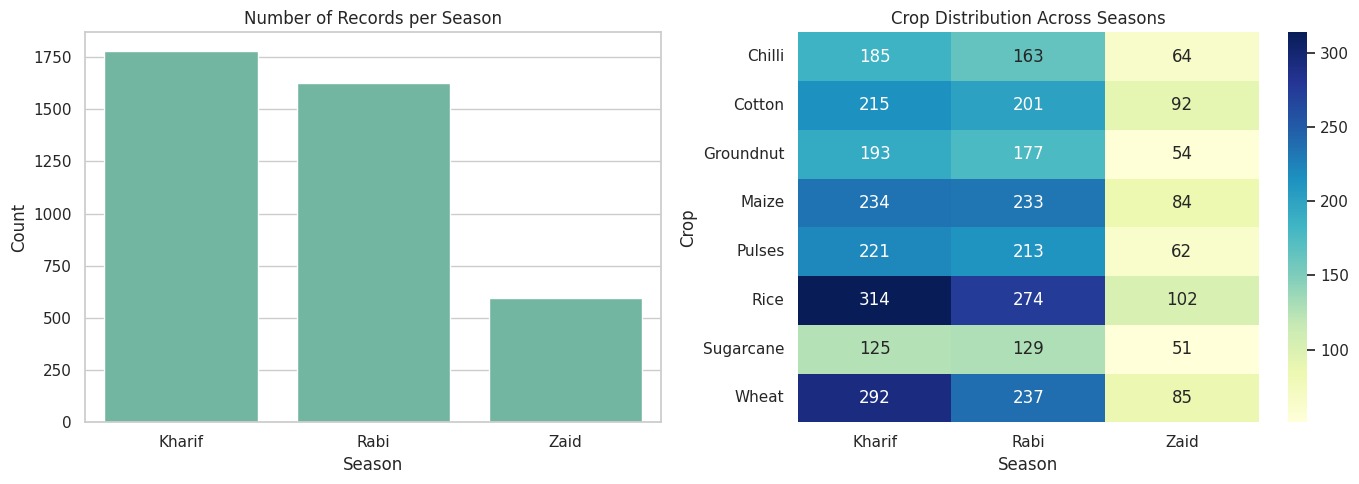

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['Kharif', 'Rabi', 'Zaid']
sns.countplot(data=df, x='Season', order=order, ax=axes[0])
axes[0].set_title('Number of Records per Season')
axes[0].set_ylabel('Count')

crop_season = pd.crosstab(df['Crop'], df['Season'])[order]
sns.heatmap(crop_season, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Crop Distribution Across Seasons')

plt.tight_layout()
plt.savefig('figures/01_season_overview.png', bbox_inches='tight')
plt.show()


**Observation:** Kharif has the most records (1,779), followed by Rabi (1,627) and Zaid (594).
All 8 crops are grown in all three seasons, but Zaid (the short summer season) has noticeably fewer
farms overall, consistent with it being a shorter, more resource-constrained cropping window.

## 6. Seasonal Environmental Conditions

How do rainfall, temperature and humidity — the core environmental drivers of agriculture — change across seasons?

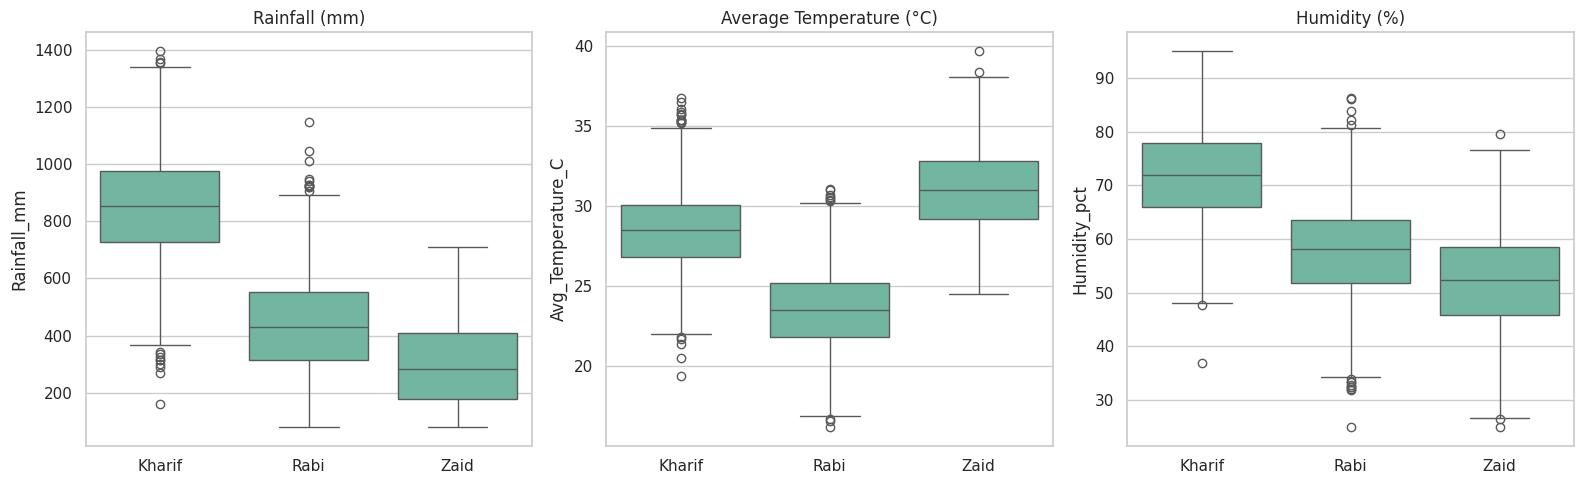

        Rainfall_mm  Avg_Temperature_C  Humidity_pct
Season                                              
Kharif       852.11              28.45         71.81
Rabi         435.94              23.49         57.89
Zaid         299.12              31.04         52.01


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

env_vars = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct']
titles = ['Rainfall (mm)', 'Average Temperature (°C)', 'Humidity (%)']

for ax, var, title in zip(axes, env_vars, titles):
    sns.boxplot(data=df, x='Season', y=var, order=order, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('figures/02_seasonal_environment.png', bbox_inches='tight')
plt.show()

print(df.groupby('Season')[env_vars].mean().reindex(order).round(2))


**Observation:** Kharif (monsoon season) receives by far the highest rainfall (~852 mm avg) and
humidity (~72%), while Zaid (summer) is the hottest (~31°C avg) and driest (~299 mm avg rainfall) with
the lowest humidity (~52%). Rabi (winter) sits in between with the mildest temperatures. This confirms
the three seasons represent genuinely distinct environmental regimes.

## 7. Seasonal Yield and Production Performance

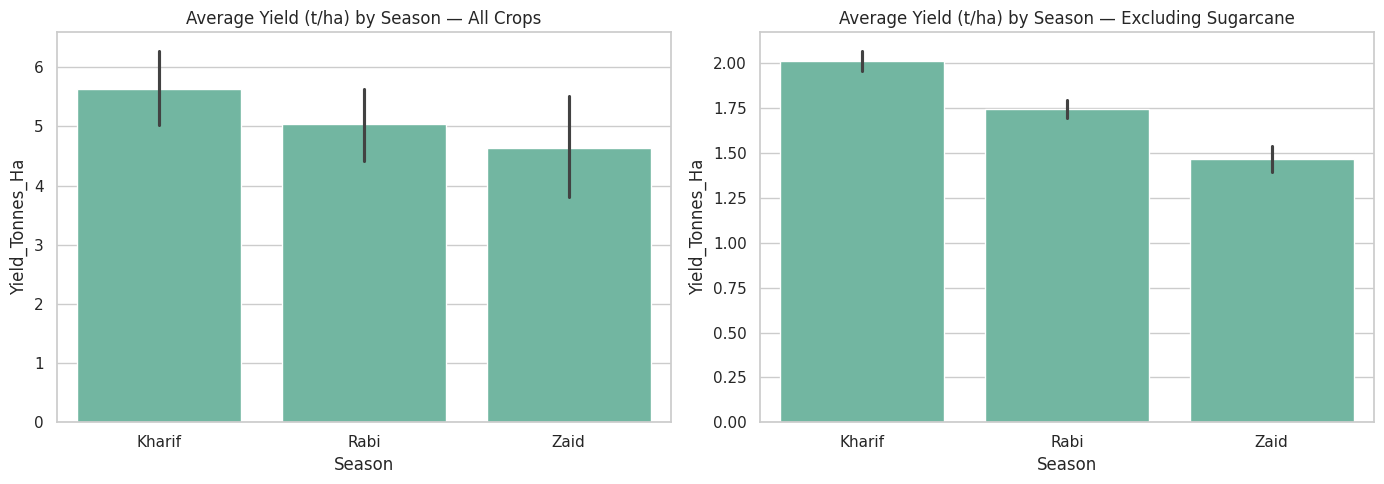

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=order, estimator=np.mean, ax=axes[0])
axes[0].set_title('Average Yield (t/ha) by Season — All Crops')

df_no_sugarcane = df[df['Crop'] != 'Sugarcane']
sns.barplot(data=df_no_sugarcane, x='Season', y='Yield_Tonnes_Ha', order=order, estimator=np.mean, ax=axes[1])
axes[1].set_title('Average Yield (t/ha) by Season — Excluding Sugarcane')

plt.tight_layout()
plt.savefig('figures/03_seasonal_yield.png', bbox_inches='tight')
plt.show()


**Observation:** At first glance, raw average yield looks fairly flat across seasons. However this is
misleading — Sugarcane (60-100+ t/ha) is present in all seasons and its scale dominates the average.
Once Sugarcane is excluded, a clear seasonal pattern emerges: **Kharif (2.02 t/ha) > Rabi (1.75 t/ha) >
Zaid (1.47 t/ha)**. This matches the environmental pattern above — the monsoon season's higher rainfall
and humidity support better yields for most crops, while the hot, dry Zaid season is the weakest performer.

*This is an important lesson for the analysis: always check whether crop composition is distorting a
seasonal comparison before drawing conclusions from raw averages.*

## 8. Seasonal Resource Usage

Comparing fertilizer, pesticide, and water usage across seasons.

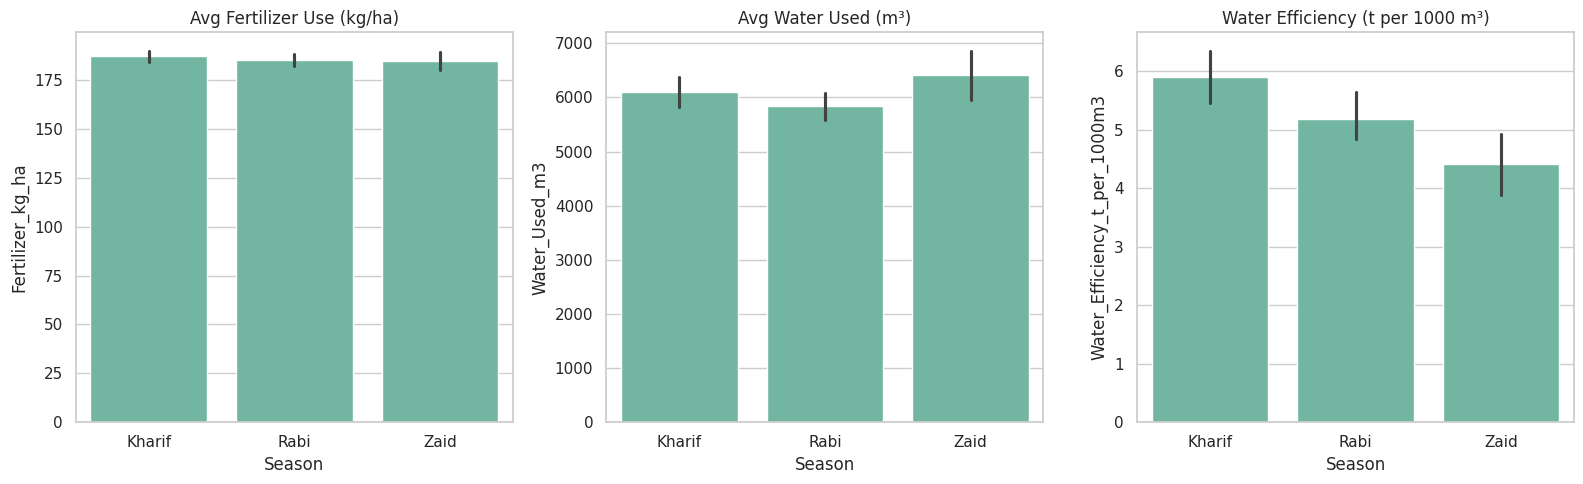

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=df, x='Season', y='Fertilizer_kg_ha', order=order, ax=axes[0])
axes[0].set_title('Avg Fertilizer Use (kg/ha)')

sns.barplot(data=df, x='Season', y='Water_Used_m3', order=order, ax=axes[1])
axes[1].set_title('Avg Water Used (m³)')

sns.barplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=order, ax=axes[2])
axes[2].set_title('Water Efficiency (t per 1000 m³)')

plt.tight_layout()
plt.savefig('figures/04_seasonal_resources.png', bbox_inches='tight')
plt.show()


**Observation:** Fertilizer use is nearly identical across seasons (~185-187 kg/ha) — farmers apply
similar nutrient doses regardless of season. Water usage, however, is **highest in Zaid (~6,420 m³)**
despite it receiving the least rainfall — farms rely heavily on irrigation to compensate. Combined with
lower Zaid yields, this results in Zaid having the **lowest water efficiency (4.41 t/1000m³)** compared
to Kharif (5.89 t/1000m³), meaning water is used least productively in the summer season.

## 9. Seasonal Economic Performance

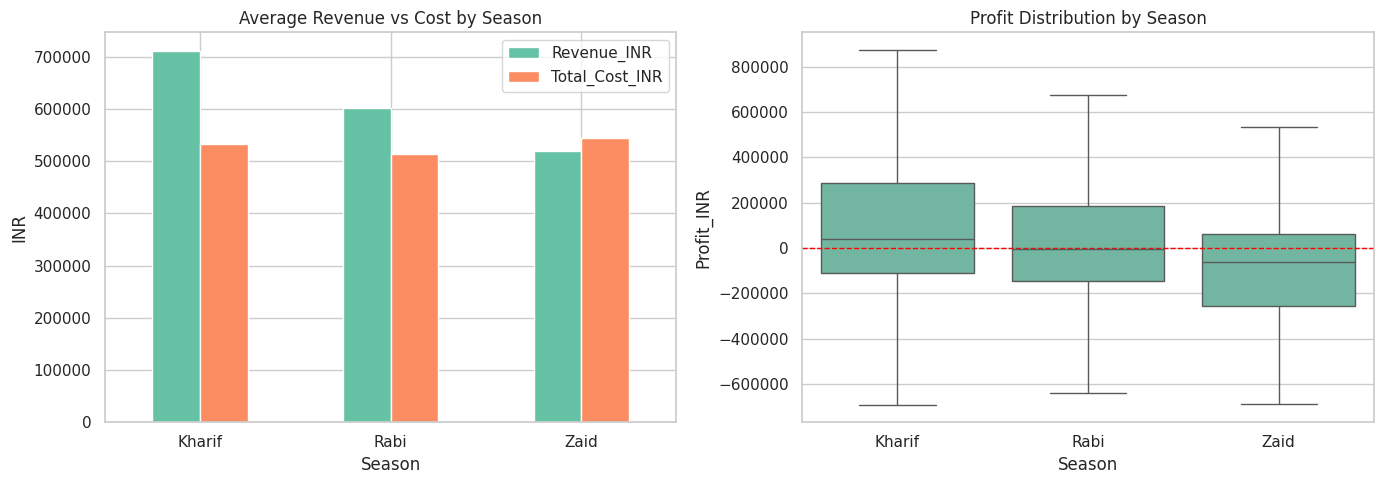

        Revenue_INR  Total_Cost_INR  Profit_INR
Season                                         
Kharif     710719.0        531804.0    178915.0
Rabi       601526.0        513837.0     87689.0
Zaid       519172.0        543977.0    -24805.0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

econ = df.groupby('Season')[['Revenue_INR','Total_Cost_INR','Profit_INR']].mean().reindex(order)
econ[['Revenue_INR','Total_Cost_INR']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Revenue vs Cost by Season')
axes[0].set_xticklabels(order, rotation=0)
axes[0].set_ylabel('INR')

sns.boxplot(data=df, x='Season', y='Profit_INR', order=order, showfliers=False, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Profit Distribution by Season')

plt.tight_layout()
plt.savefig('figures/05_seasonal_economics.png', bbox_inches='tight')
plt.show()

print(econ.round(0))


**Observation:** This is one of the sharpest seasonal differences in the dataset. Average profit
falls steadily from **₹1,78,915 in Kharif**, to **₹87,689 in Rabi**, to a **loss of ₹-24,805 in Zaid**.
Costs stay relatively stable across seasons (~₹5.1-5.4 lakh), but **revenue drops substantially** in
Zaid (~₹5.19 lakh vs ~₹7.11 lakh in Kharif) — driven by lower yields and production. Farming in the
Zaid season is, on average, **loss-making** in this dataset.

## 10. Disease and Pest Risk Across Seasons

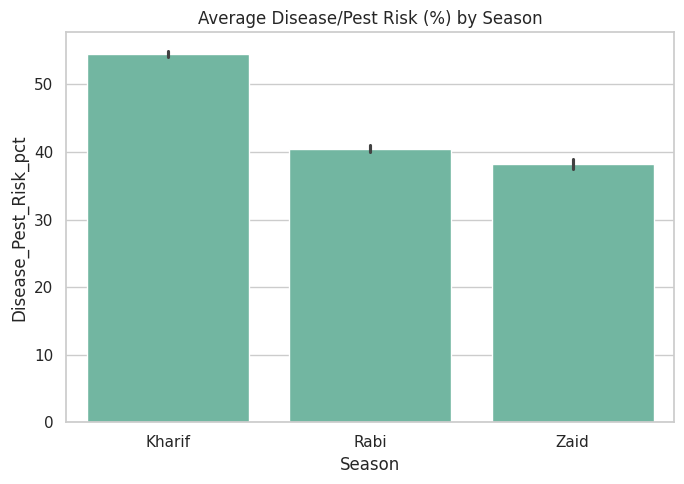

Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64


In [14]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=order)
plt.title('Average Disease/Pest Risk (%) by Season')
plt.tight_layout()
plt.savefig('figures/06_disease_risk.png', bbox_inches='tight')
plt.show()

print(df.groupby('Season')['Disease_Pest_Risk_pct'].mean().reindex(order).round(2))


**Observation:** Disease/pest risk is markedly higher in **Kharif (~54.5%)** than in Rabi (~40.5%)
or Zaid (~38.2%). This makes agronomic sense — the humidity and rainfall that make Kharif the most
productive season also create favourable conditions for pests and fungal diseases, so higher yield in
this season comes with a genuine trade-off in crop protection effort.

## 11. Relationships Between Variables

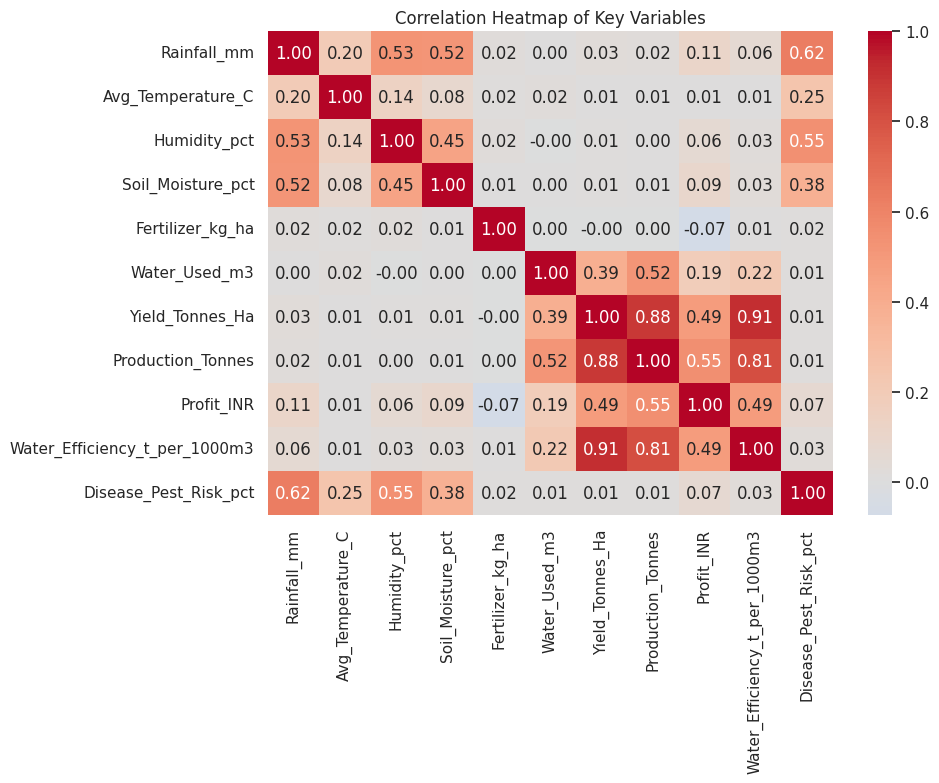

In [15]:
num_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct',
            'Fertilizer_kg_ha','Water_Used_m3','Yield_Tonnes_Ha','Production_Tonnes',
            'Profit_INR','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']

plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Key Variables')
plt.tight_layout()
plt.savefig('figures/07_correlation_heatmap.png', bbox_inches='tight')
plt.show()


**Observation:** `Water_Efficiency` is very strongly correlated with `Yield` (as expected, since
efficiency is derived from yield per unit water). `Yield` and `Production` are also strongly linked to
`Profit`. Interestingly, raw `Rainfall` and `Temperature` show weak *direct* correlation with yield at
the individual-farm level — their effect works mainly *through* the season-level shifts in water
availability and crop choice we already observed, rather than as a simple linear relationship within a season.

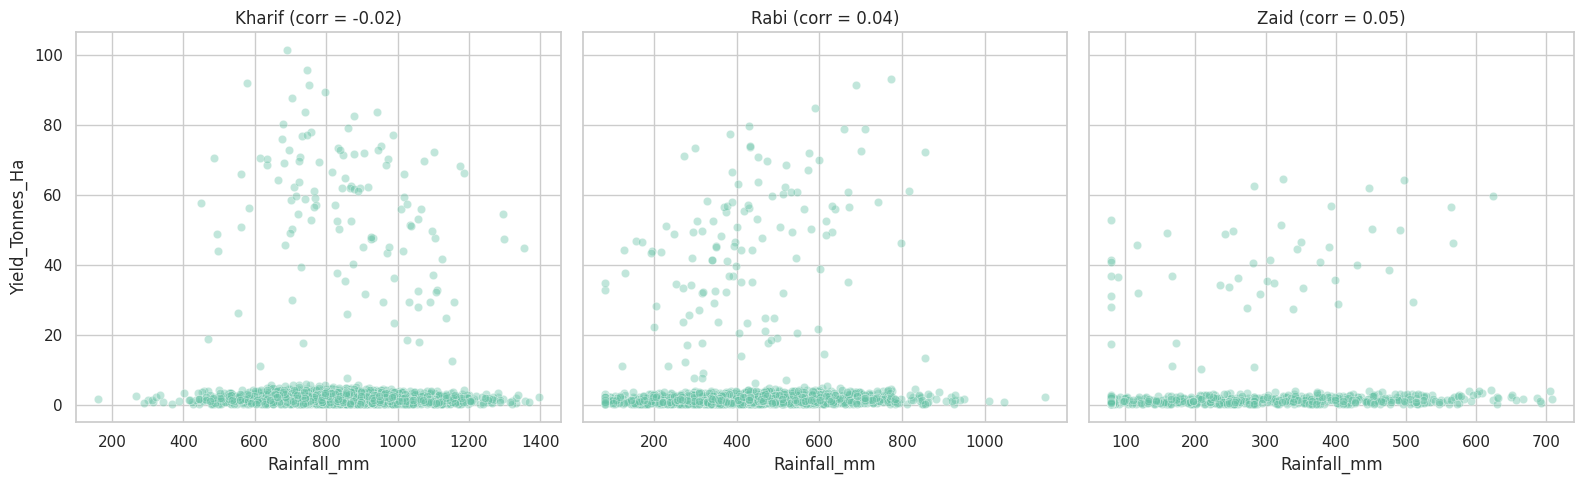

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16,5), sharey=True)
for ax, s in zip(axes, order):
    sub = df[df['Season']==s]
    sns.scatterplot(data=sub, x='Rainfall_mm', y='Yield_Tonnes_Ha', alpha=0.4, ax=ax)
    corr = sub['Rainfall_mm'].corr(sub['Yield_Tonnes_Ha'])
    ax.set_title(f'{s} (corr = {corr:.2f})')
plt.tight_layout()
plt.savefig('figures/08_rainfall_vs_yield.png', bbox_inches='tight')
plt.show()


**Observation:** Within each individual season, rainfall does not show a strong linear relationship
with yield (correlations near zero in all three seasons). This suggests that once a farm is already
operating within a given season's typical rainfall band, other factors — crop type, irrigation method,
soil, and farming practice — matter more for yield outcomes than small variations in rainfall itself.

## 12. Impact of Irrigation Method

                   Water_Used_m3  Water_Efficiency_t_per_1000m3  Profit_INR
Irrigation_Method                                                          
Drip                     5918.75                           6.27   219626.00
Flood                    8026.47                           3.44    73354.02
Rainfed                  3549.55                           7.56    79050.37
Sprinkler                6208.26                           4.67    91121.08


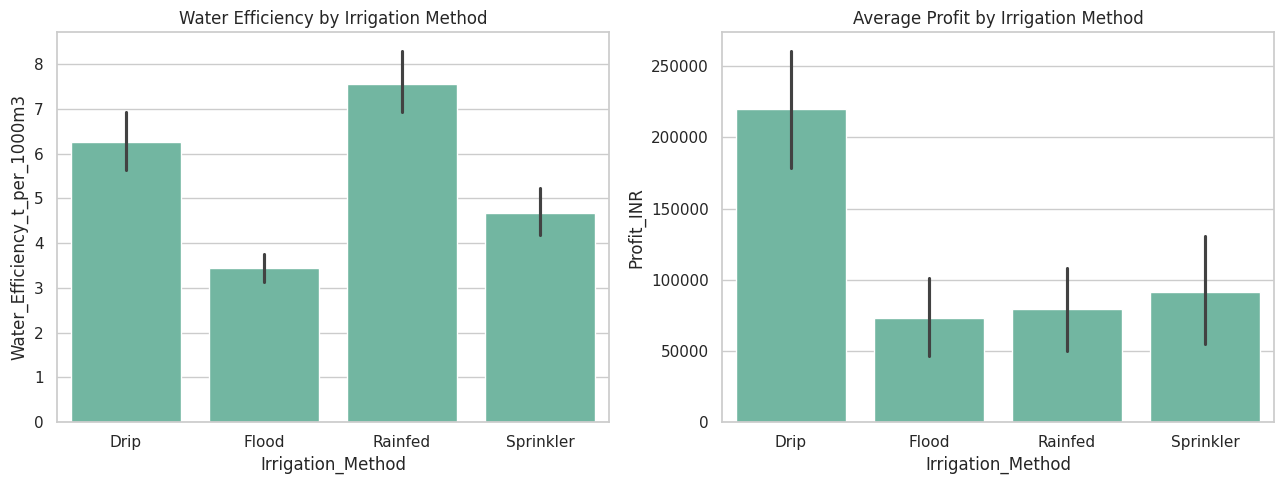

In [17]:
irr_summary = df.groupby('Irrigation_Method')[['Water_Used_m3','Water_Efficiency_t_per_1000m3','Profit_INR']].mean().round(2)
print(irr_summary)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.barplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', ax=axes[0])
axes[0].set_title('Water Efficiency by Irrigation Method')
sns.barplot(data=df, x='Irrigation_Method', y='Profit_INR', ax=axes[1])
axes[1].set_title('Average Profit by Irrigation Method')
plt.tight_layout()
plt.savefig('figures/09_irrigation_method.png', bbox_inches='tight')
plt.show()


**Observation:** **Drip irrigation** delivers by far the best profit outcome (~₹2.2 lakh avg) with
strong water efficiency, despite not using the least water overall. **Flood irrigation**, the most
water-intensive method, has the **lowest water efficiency (3.44 t/1000m³)** and among the lowest average
profit (~₹73,354) — using the most water for comparatively the poorest return. This pattern holds
consistently across all three seasons, suggesting irrigation method is a key lever independent of season.

## 13. Crop Performance Across Seasons

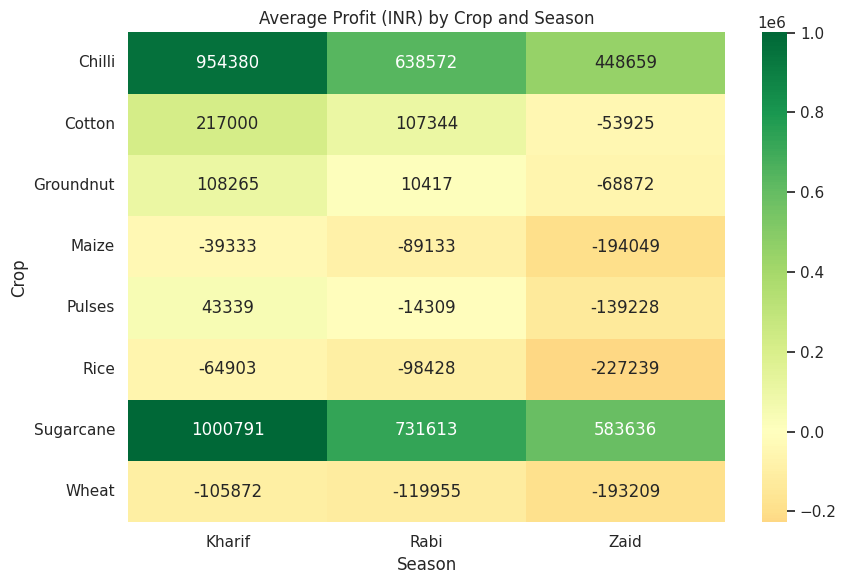

In [18]:
crop_profit = df.groupby(['Crop','Season'])['Profit_INR'].mean().unstack()[order]
plt.figure(figsize=(9,6))
sns.heatmap(crop_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR) by Crop and Season')
plt.tight_layout()
plt.savefig('figures/10_crop_season_profit.png', bbox_inches='tight')
plt.show()


**Observation:** **Sugarcane and Chilli** are consistently profitable across all three seasons and
are the strongest overall performers. **Wheat and Rice**, by contrast, run at a **loss in every single
season** in this dataset, with the loss deepening in Zaid. This tells us the seasonal profit decline
identified earlier is not uniform — it is concentrated in specific crops, and diversifying toward
higher-margin crops like Chilli or Sugarcane could offset seasonal downturns, especially in Zaid.

## 14. Regional (State-wise) Patterns

Are the seasonal patterns consistent across states, or do some regions behave differently?

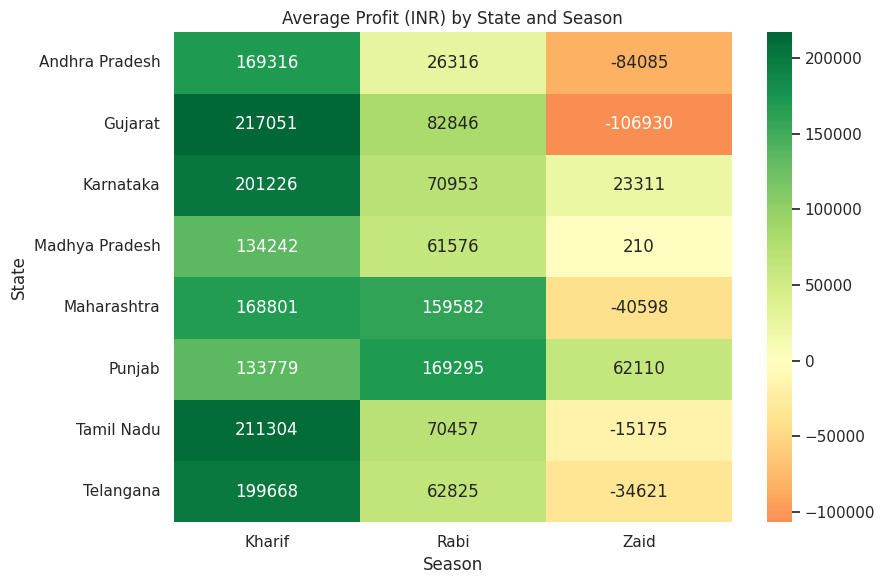

In [19]:
state_season_profit = df.groupby(['State','Season'])['Profit_INR'].mean().unstack()[order]
plt.figure(figsize=(9,6))
sns.heatmap(state_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR) by State and Season')
plt.tight_layout()
plt.savefig('figures/11_state_season_profit.png', bbox_inches='tight')
plt.show()


**Observation:** The Kharif > Rabi > Zaid profit pattern holds true for **most states**, confirming
it is a genuine seasonal effect rather than an artifact of a specific region. However, the *magnitude* of
the Zaid slump varies — some states dip only mildly while others show much steeper losses, suggesting
local factors (irrigation infrastructure, soil, crop choice) moderate how badly a region is affected by
the difficult summer season.

## 15. Statistical Significance Testing

To confirm the seasonal differences observed are statistically meaningful and not just due to random
variation, we run one-way ANOVA tests comparing Kharif, Rabi and Zaid on key metrics.

In [20]:
def run_anova(column, label, exclude_sugarcane=False):
    data = df[df['Crop'] != 'Sugarcane'] if exclude_sugarcane else df
    groups = [g[column].dropna().values for _, g in data.groupby('Season')]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = "Statistically significant (p < 0.05)" if p_val < 0.05 else "Not statistically significant"
    print(f"{label}: F = {f_stat:.2f}, p = {p_val:.4g}  ->  {sig}")

run_anova('Yield_Tonnes_Ha', 'Yield (excluding Sugarcane)', exclude_sugarcane=True)
run_anova('Profit_INR', 'Profit')
run_anova('Water_Efficiency_t_per_1000m3', 'Water Efficiency')
run_anova('Disease_Pest_Risk_pct', 'Disease/Pest Risk')


Yield (excluding Sugarcane): F = 61.09, p = 7.902e-27  ->  Statistically significant (p < 0.05)
Profit: F = 34.29, p = 1.712e-15  ->  Statistically significant (p < 0.05)
Water Efficiency: F = 6.95, p = 0.0009719  ->  Statistically significant (p < 0.05)
Disease/Pest Risk: F = 1049.47, p = 0  ->  Statistically significant (p < 0.05)


**Result:** All four metrics show statistically significant differences across seasons
(p < 0.05), confirming that season is a genuine, measurable driver of agricultural performance in this
dataset — not just random noise between groups.

## 16. Key Insights Summary

1. **Kharif is the strongest season overall** — highest rainfall/humidity, highest yield (once crop mix is controlled for), and by far the highest average profit (~₹1.79 lakh).
2. **Zaid is the weakest and often loss-making season** — lowest rainfall and yield, highest water usage despite that, the lowest water efficiency, and a **negative average profit** (~₹-24,805).
3. **Raw yield comparisons can mislead** — Sugarcane's very high yield scale masks a real, statistically significant seasonal yield decline (Kharif → Rabi → Zaid) that only appears once crop composition is accounted for.
4. **Higher yield in Kharif comes with a trade-off**: disease/pest risk is also highest in this season (~54.5%) due to the same humidity and rainfall that boost productivity.
5. **Irrigation method matters more than season** for profitability — Drip irrigation consistently outperforms Flood irrigation on both water efficiency and profit, in every season.
6. **Crop choice drives much of the seasonal profit story** — Sugarcane and Chilli are profitable in every season, while Wheat and Rice are loss-making in every season, meaning the "seasonal decline" is concentrated in specific crops rather than uniform across all farming.
7. **The seasonal pattern is broadly consistent across the 8 states** studied, though the severity of the Zaid downturn varies by region.
8. All observed seasonal differences in profit, water efficiency, disease risk, and (crop-adjusted) yield are **statistically significant**, not random variation.


## 17. Recommendations

- **Prioritize drip irrigation** over flood irrigation wherever feasible — it consistently delivers better water efficiency and profitability across all seasons.
- **Reconsider crop selection for Zaid season** — given consistently weak yields and profits, shifting a larger share of Zaid-season land toward higher-margin, more drought-tolerant crops (e.g., Chilli) could reduce the summer loss.
- **Strengthen pest/disease management specifically in Kharif** — since the season's higher humidity drives up disease/pest risk, targeted crop protection investment here could help capture more of Kharif's yield potential.
- **Re-evaluate Wheat and Rice profitability** — both run at a loss across all three seasons in this dataset; a cost/pricing review or a shift toward better-performing crops in these farms may be warranted.
- **Use season-adjusted, crop-adjusted benchmarks** (not simple overall averages) for any future agricultural planning or policy decisions, since raw aggregates can be distorted by crop mix, as shown in the yield analysis.

## 18. Conclusion

This analysis confirms that agricultural performance in this dataset varies significantly across the
three cropping seasons. **Kharif is the most productive and profitable season**, supported by favourable
rainfall and humidity, though it carries higher disease/pest risk. **Zaid is the most challenging
season**, marked by heat, water stress, low water-use efficiency, and — on average — financial loss.
Beyond season alone, **irrigation method and crop choice emerge as equally important, statistically
significant levers** that farmers and planners can act on to improve outcomes, particularly during the
difficult Zaid season.
